In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
# Load the input image
image = cv2.imread("imge.jpg")

if image is None:
    print("Image not found!")
else:
    print("Image loaded successfully")

Image loaded successfully


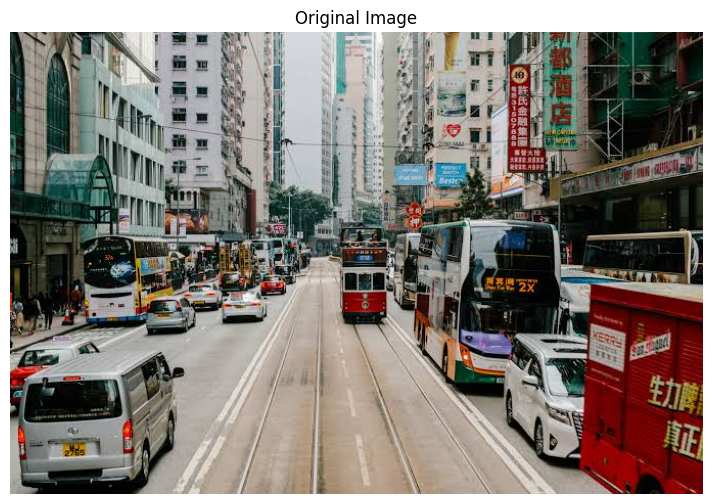

In [ ]:
# Display the original image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Original Image")
plt.show()

In [ ]:
# Display image dimensions and properties
print("Image Height:", image.shape[0])
print("Image Width:", image.shape[1])
print("Number of Channels:", image.shape[2])

Image Height: 452
Image Width: 678
Number of Channels: 3


In [ ]:
# Perform object detection using YOLOv8
results = model(image)


0: 448x640 8 cars, 5 buss, 397.0ms
Speed: 24.9ms preprocess, 397.0ms inference, 36.5ms postprocess per image at shape (1, 3, 448, 640)


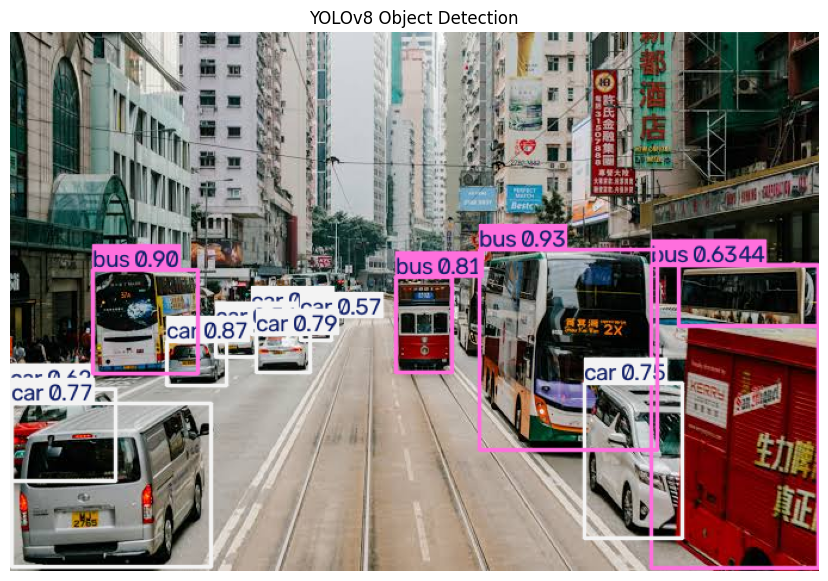

In [ ]:
# Draw bounding boxes and labels on detected objects
result_image = results[0].plot()

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLOv8 Object Detection")
plt.show()

In [ ]:
# Display detected object names and confidence scores
print("Detected Objects:\n")

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]

        print(
            "Object:", class_name,
            "| Confidence:", round(confidence, 2)
        )

Detected Objects:

Object: bus | Confidence: 0.93
Object: bus | Confidence: 0.9
Object: car | Confidence: 0.87
Object: bus | Confidence: 0.81
Object: car | Confidence: 0.79
Object: car | Confidence: 0.77
Object: car | Confidence: 0.75
Object: bus | Confidence: 0.63
Object: car | Confidence: 0.62
Object: car | Confidence: 0.57
Object: car | Confidence: 0.54
Object: bus | Confidence: 0.44
Object: car | Confidence: 0.32


In [ ]:
# Display bounding box coordinates of detected objects
print("Bounding Box Coordinates:\n")

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        coordinates = box.xyxy[0].tolist()

        print(class_name, ":", coordinates)

Bounding Box Coordinates:

bus : [393.2771301269531, 182.55393981933594, 542.7049560546875, 350.9891357421875]
bus : [69.83045959472656, 199.03651428222656, 157.6262969970703, 286.2942199707031]
car : [131.82228088378906, 259.2010498046875, 181.96847534179688, 296.1804504394531]
bus : [323.37921142578125, 205.54849243164062, 370.19537353515625, 285.17852783203125]
car : [206.11920166015625, 253.1804962158203, 251.85308837890625, 285.1299743652344]
car : [1.888127088546753, 311.79998779296875, 168.91488647460938, 448.71966552734375]
car : [481.5884094238281, 294.36279296875, 563.2861328125, 424.7942810058594]
bus : [537.5159912109375, 195.02081298828125, 677.65234375, 449.5572814941406]
car : [0.0, 299.75146484375, 88.1322250366211, 376.2051696777344]
car : [243.99803161621094, 239.2501220703125, 269.7060546875, 258.4474792480469]
car : [172.48709106445312, 247.34434509277344, 206.21536254882812, 272.71746826171875]
bus : [560.2023315429688, 195.05955505371094, 677.5852661132812, 246.90

In [ ]:
# Count the total number of detected objects
total_objects = len(results[0].boxes)

print("Total Objects Detected:", total_objects)

Total Objects Detected: 13



0: 448x640 7 cars, 4 buss, 155.9ms
Speed: 7.2ms preprocess, 155.9ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


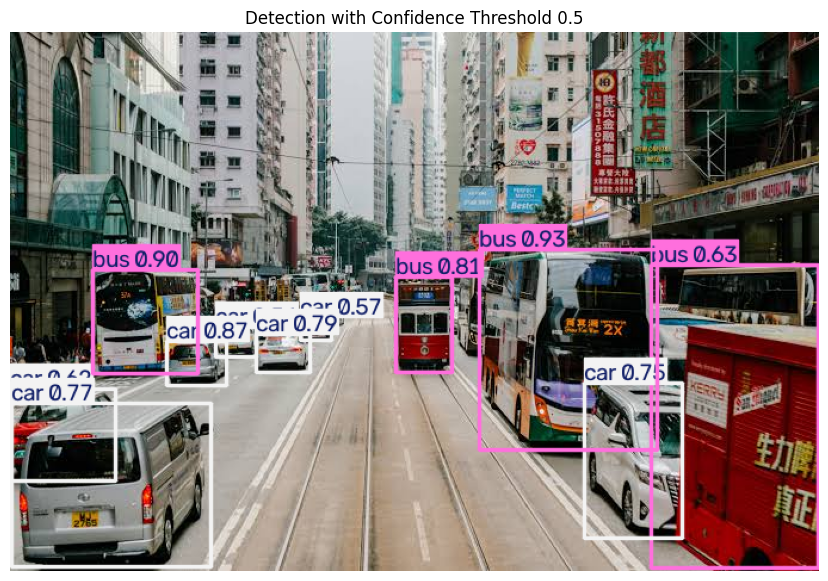

In [ ]:
# Perform detection with a confidence threshold of 50%
results_conf = model(image, conf=0.5)

result_conf_image = results_conf[0].plot()

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(result_conf_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detection with Confidence Threshold 0.5")
plt.show()

In [ ]:
# Display objects detected with confidence greater than 50%
print("High Confidence Detections:\n")

for result in results_conf:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]

        print(
            f"{class_name} -> Confidence: {confidence:.2f}"
        )

High Confidence Detections:

bus -> Confidence: 0.93
bus -> Confidence: 0.90
car -> Confidence: 0.87
bus -> Confidence: 0.81
car -> Confidence: 0.79
car -> Confidence: 0.77
car -> Confidence: 0.75
bus -> Confidence: 0.63
car -> Confidence: 0.62
car -> Confidence: 0.57
car -> Confidence: 0.54


In [ ]:
# Save the detected image
cv2.imwrite("detected_objects.jpg", result_conf_image)

print("Detection result saved as detected_objects.jpg")

Detection result saved as detected_objects.jpg


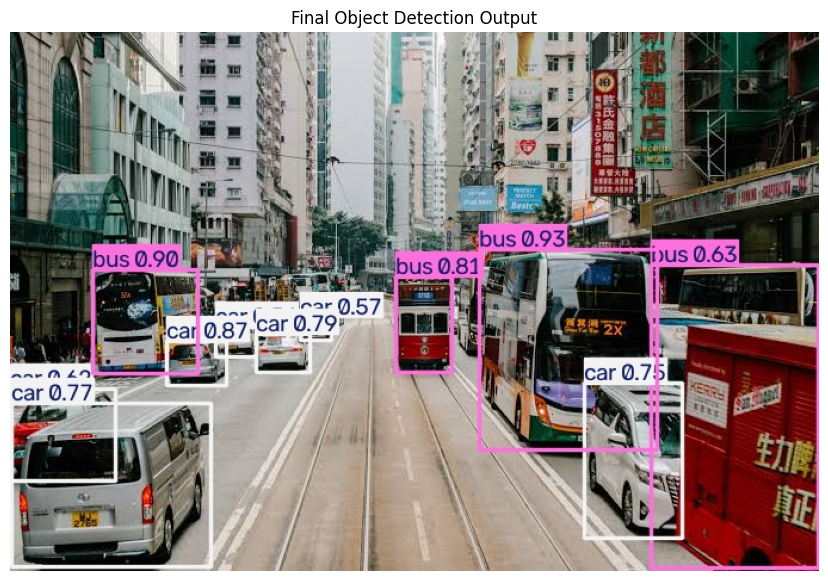

In [ ]:
# Display the saved detection result
output = cv2.imread("detected_objects.jpg")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Final Object Detection Output")
plt.show()

In [ ]:
# Display final observation
print("Observation:")
print("YOLOv8 successfully detected and localized multiple objects.")
print("Each detected object contains a class label, confidence score,")
print("and bounding box coordinates.")

Observation:
YOLOv8 successfully detected and localized multiple objects.
Each detected object contains a class label, confidence score,
and bounding box coordinates.
